# Task-1: Multimodal Retrieval-Augmented Generation (RAG) System

---

## ⚠️ **IMPORTANT: GPU REQUIRED**

**🚨 Before running this notebook:**
1. Click **Settings** (gear icon on the right)
2. Under **Accelerator**, select **"GPU T4 x2"** or **"GPU P100"**
3. Click **Save**
4. **This notebook will fail without GPU** (enforced in code)

**Why?** Mistral-7B inference on CPU takes 5-10 minutes per query (unusable).  
**With GPU:** 10-30 seconds per query ⚡

---

## Overview
This notebook implements a complete Multimodal RAG pipeline that:
- Extracts text and images from PDF documents
- Creates embeddings for both text and visual content
- Stores data in a vector database (FAISS)
- Retrieves relevant information based on queries
- Generates responses using Mistral-7B-Instruct LLM
- Provides a ChatGPT-like web interface using Gradio

## System Architecture
1. **Data Extraction**: PDF parsing, text extraction, image extraction
2. **Embedding Generation**: Sentence-BERT for text, CLIP for images
3. **Vector Storage**: FAISS for efficient similarity search
4. **Retrieval System**: Semantic search for text and image queries
5. **LLM Integration**: Mistral-7B-Instruct with advanced prompting
6. **User Interface**: Gradio web app with text/image query support
7. **Evaluation**: Metrics and visualizations


## ⚡ Quick Setup Checklist

**Before running any cells, complete these steps:**

### Step 1: Enable GPU in Kaggle
- [ ] Click **"Settings"** (gear icon on right sidebar)
- [ ] Under **"Accelerator"**, select **"GPU T4 x2"** (or GPU P100)
- [ ] Click **"Save"**

### Step 2: Verify GPU Enabled
- [ ] Look at the top-right corner of the notebook
- [ ] You should see: **"GPU P100"** or **"GPU T4 x2"** (not "CPU")
- [ ] If it still says CPU, refresh the page after saving settings

### Step 3: Run Cells in Order
- [ ] Run **Cell 2** (Installation) - Takes 2-3 minutes
- [ ] **IMPORTANT:** Check Cell 2 output shows "CUDA available: True"
- [ ] If it shows False, **restart kernel** and rerun Cell 2
- [ ] Run **Cell 3** - Should show "Using device: cuda"
- [ ] Continue with remaining cells

### ⚠️ Common Issue:
If Cell 3 shows `Using device: cpu`:
1. **Restart Kernel** (Kernel → Restart & Clear Output)
2. Verify GPU is shown in top-right corner
3. Rerun Cell 2 (it will detect and fix PyTorch)
4. Rerun Cell 3 (should now show cuda)

---


## 1. Installation and Setup


In [ ]:
# Install required libraries
# NOTE: On Kaggle, PyTorch with CUDA is pre-installed

import sys
import subprocess

# Check PyTorch and CUDA availability
print("="*60)
print("CHECKING GPU AND PYTORCH")
print("="*60)

try:
    import torch
    print(f"✓ PyTorch version: {torch.__version__}")
    print(f"✓ CUDA available: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"✓ CUDA version: {torch.version.cuda}")
        print(f"✓ GPU device: {torch.cuda.get_device_name(0)}")
        print(f"✓ GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        print("\n❌ ERROR: CUDA NOT AVAILABLE!")
        print("⚠️  Please enable GPU in Kaggle:")
        print("   1. Click Settings (gear icon)")
        print("   2. Select Accelerator → GPU T4 x2")
        print("   3. Click Save and restart notebook")
        raise RuntimeError("GPU required but not available!")
    
    print("\n✓ GPU check passed! Proceeding with installation...")
    
except ImportError:
    print("⚠️  PyTorch not found. Installing with CUDA support...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/cu118"
    ])
    print("✓ PyTorch installed!")
    import torch

print("="*60)

# Install other required libraries
%pip install -q pymupdf pillow pytesseract pdf2image
%pip install -q sentence-transformers transformers accelerate bitsandbytes
%pip install -q faiss-cpu  # faiss-cpu works fine with CUDA PyTorch!
%pip install -q gradio
%pip install -q matplotlib seaborn numpy pandas scikit-learn
%pip install -q rouge-score nltk
%pip install -q ftfy regex tqdm
%pip install -q git+https://github.com/openai/CLIP.git

print("\n" + "="*60)
print("✓ All libraries installed successfully!")
print("="*60)


In [1]:
# Import all required libraries
import os
import json
import base64
import time
from io import BytesIO
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Union
import warnings
warnings.filterwarnings('ignore')

# PDF Processing
import fitz  # PyMuPDF
from PIL import Image

# ML/DL Libraries
# Force reload torch to ensure we get the CUDA version
import importlib
import sys
if 'torch' in sys.modules:
    import torch
    importlib.reload(torch)
else:
    import torch

import torch.nn.functional as F
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM, 
    BitsAndBytesConfig,
    pipeline
)

# Install and import CLIP
try:
    import clip
    print("✓ CLIP already installed")
except ImportError:
    print("⚠ CLIP not found. Installing...")
    import subprocess
    import sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/openai/CLIP.git"
    ])
    import clip
    print("✓ CLIP installed successfully")

# Vector Database
import faiss

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Evaluation
from rouge_score import rouge_scorer
import nltk
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    pass

# UI
import gradio as gr

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
print("\n" + "="*60)
print("VERIFYING GPU SETUP")
print("="*60)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Using device: {device}")
print(f"✓ PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"✓ CUDA is available!")
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ CUDA Version: {torch.version.cuda}")
else:
    print("\n⚠️  WARNING: CUDA not available!")
    print("⚠️  If you enabled GPU in Kaggle settings:")
    print("    1. Restart the kernel (Kernel → Restart)")
    print("    2. Rerun Cell 2 to install PyTorch with CUDA")
    print("    3. Then rerun this cell")
    print("\n⚠️  The notebook will fail at model loading without GPU!")

print("="*60)


2025-11-25 18:22:25.475469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764094945.673505     165 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764094945.734562     165 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ CLIP already installed

VERIFYING GPU SETUP
✓ Using device: cuda
✓ PyTorch version: 2.6.0+cu124
✓ CUDA is available!
✓ GPU: Tesla T4
✓ GPU Memory: 15.83 GB
✓ CUDA Version: 12.4


## 2. Data Extraction and Preprocessing

### 2.1 PDF Extraction Class


In [2]:
class PDFExtractor:
    """Extract text, images, and tables from PDF documents."""
    
    def __init__(self, pdf_dir: str = "./Data"):
        self.pdf_dir = Path(pdf_dir)
        self.documents = []
        
    def extract_tables(self, page) -> List[Dict]:
        """Extract tables from a PDF page using text-based detection."""
        tables = []
        text = page.get_text("text")
        
        # Detect table-like structures (rows with multiple columns separated by spaces/tabs)
        lines = text.split('\n')
        table_rows = []
        current_table = []
        
        for line in lines:
            # Check if line looks like a table row (multiple columns)
            parts = [p.strip() for p in line.split('\t') if p.strip()]
            if len(parts) < 2:
                parts = [p.strip() for p in line.split('  ') if p.strip()]  # Try double spaces
            
            # If line has multiple columns and looks structured
            if len(parts) >= 2 and any(len(p) > 0 for p in parts):
                # Check if it contains numbers (likely financial data)
                has_numbers = any(any(c.isdigit() for c in part) for part in parts)
                if has_numbers or len(parts) >= 3:
                    current_table.append(parts)
                else:
                    if len(current_table) >= 2:  # At least 2 rows to be a table
                        table_text = '\n'.join([' | '.join(row) for row in current_table])
                        tables.append({
                            'content': table_text,
                            'rows': len(current_table),
                            'columns': max(len(row) for row in current_table) if current_table else 0
                        })
                    current_table = []
            else:
                if len(current_table) >= 2:
                    table_text = '\n'.join([' | '.join(row) for row in current_table])
                    tables.append({
                        'content': table_text,
                        'rows': len(current_table),
                        'columns': max(len(row) for row in current_table) if current_table else 0
                    })
                current_table = []
        
        # Add last table if exists
        if len(current_table) >= 2:
            table_text = '\n'.join([' | '.join(row) for row in current_table])
            tables.append({
                'content': table_text,
                'rows': len(current_table),
                'columns': max(len(row) for row in current_table) if current_table else 0
            })
        
        return tables
        
    def extract_financial_figures(self, text: str) -> List[Dict]:
        """Extract financial figures (numbers with currency symbols, percentages, etc.)."""
        import re
        financial_figures = []
        
        # Pattern for currency amounts (e.g., $1,234.56, €1,234.56, £1,234.56)
        currency_pattern = r'[\$€£¥]\s*[\d,]+\.?\d*\s*(?:million|billion|thousand|M|B|K)?'
        
        # Pattern for percentages
        percentage_pattern = r'\d+\.?\d*\s*%'
        
        # Pattern for large numbers (likely financial)
        large_number_pattern = r'\b\d{1,3}(?:,\d{3})*(?:\.\d{2})?\b'
        
        # Find all matches
        currency_matches = re.finditer(currency_pattern, text, re.IGNORECASE)
        percentage_matches = re.finditer(percentage_pattern, text)
        number_matches = re.finditer(large_number_pattern, text)
        
        for match in currency_matches:
            financial_figures.append({
                'type': 'currency',
                'value': match.group(),
                'position': match.start()
            })
        
        for match in percentage_matches:
            financial_figures.append({
                'type': 'percentage',
                'value': match.group(),
                'position': match.start()
            })
        
        # Filter large numbers (likely financial if > 1000)
        for match in number_matches:
            num_str = match.group().replace(',', '')
            try:
                num_val = float(num_str)
                if num_val >= 1000:  # Likely a financial figure
                    financial_figures.append({
                        'type': 'large_number',
                        'value': match.group(),
                        'position': match.start()
                    })
            except:
                pass
        
        return financial_figures
        
    def extract_from_pdf(self, pdf_path: Path) -> Dict:
        """Extract text, images, tables, and financial figures from a single PDF."""
        doc = fitz.open(pdf_path)
        extracted_data = {
            'filename': pdf_path.name,
            'total_pages': len(doc),
            'text_chunks': [],
            'images': [],
            'tables': [],
            'financial_figures': []
        }
        
        print(f"\nProcessing: {pdf_path.name}")
        print(f"Total pages: {len(doc)}")
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            
            # Extract text
            text = page.get_text("text")
            if text.strip():
                # Extract financial figures from page text
                page_figures = self.extract_financial_figures(text)
                extracted_data['financial_figures'].extend([
                    {**fig, 'page': page_num + 1, 'source': pdf_path.name} 
                    for fig in page_figures
                ])
                
                # Split text into chunks (by paragraphs or sentences)
                paragraphs = text.split('\n\n')
                for para_idx, para in enumerate(paragraphs):
                    if len(para.strip()) > 50:  # Only keep substantial chunks
                        extracted_data['text_chunks'].append({
                            'content': para.strip(),
                            'page': page_num + 1,
                            'chunk_id': f"{pdf_path.stem}_p{page_num+1}_c{para_idx}",
                            'type': 'text',
                            'source': pdf_path.name
                        })
            
            # Extract tables
            tables = self.extract_tables(page)
            for table_idx, table in enumerate(tables):
                extracted_data['tables'].append({
                    'content': table['content'],
                    'page': page_num + 1,
                    'table_id': f"{pdf_path.stem}_p{page_num+1}_t{table_idx}",
                    'type': 'table',
                    'source': pdf_path.name,
                    'rows': table['rows'],
                    'columns': table['columns']
                })
            
            # Extract images
            image_list = page.get_images(full=True)
            for img_idx, img in enumerate(image_list):
                try:
                    xref = img[0]
                    base_image = doc.extract_image(xref)
                    image_bytes = base_image["image"]
                    image_ext = base_image["ext"]
                    
                    # Convert to PIL Image
                    pil_image = Image.open(BytesIO(image_bytes))
                    
                    # Only keep reasonably sized images (likely charts/graphs)
                    if pil_image.width > 100 and pil_image.height > 100:
                        extracted_data['images'].append({
                            'image': pil_image,
                            'page': page_num + 1,
                            'image_id': f"{pdf_path.stem}_p{page_num+1}_img{img_idx}",
                            'type': 'image',
                            'source': pdf_path.name,
                            'size': (pil_image.width, pil_image.height)
                        })
                except Exception as e:
                    print(f"  Warning: Could not extract image {img_idx} from page {page_num+1}: {e}")
        
        doc.close()
        
        print(f"  Extracted {len(extracted_data['text_chunks'])} text chunks")
        print(f"  Extracted {len(extracted_data['images'])} images")
        print(f"  Extracted {len(extracted_data['tables'])} tables")
        print(f"  Extracted {len(extracted_data['financial_figures'])} financial figures")
        
        return extracted_data
    
    def extract_all(self) -> List[Dict]:
        """Extract from all PDFs in the directory."""
        pdf_files = list(self.pdf_dir.glob("*.pdf"))
        
        if not pdf_files:
            print(f"No PDF files found in {self.pdf_dir}")
            return []
        
        print(f"Found {len(pdf_files)} PDF files")
        
        for pdf_path in pdf_files:
            try:
                data = self.extract_from_pdf(pdf_path)
                self.documents.append(data)
            except Exception as e:
                print(f"Error processing {pdf_path.name}: {e}")
        
        return self.documents
    
    def get_statistics(self) -> Dict:
        """Get extraction statistics."""
        total_text_chunks = sum(len(doc['text_chunks']) for doc in self.documents)
        total_images = sum(len(doc['images']) for doc in self.documents)
        total_pages = sum(doc['total_pages'] for doc in self.documents)
        
        return {
            'total_documents': len(self.documents),
            'total_pages': total_pages,
            'total_text_chunks': total_text_chunks,
            'total_images': total_images
        }

# Initialize and run extraction
print("="*60)
print("STEP 1: PDF EXTRACTION")
print("="*60)

extractor = PDFExtractor("/kaggle/input/dataset4")
documents = extractor.extract_all()
stats = extractor.get_statistics()

print("\n" + "="*60)
print("EXTRACTION STATISTICS")
print("="*60)
for key, value in stats.items():
    print(f"{key}: {value}")
print("="*60)


STEP 1: PDF EXTRACTION
Found 3 PDF files

Processing: 3. FYP-Handbook-2023.pdf
Total pages: 62
  Extracted 28 text chunks
  Extracted 242 images
  Extracted 1 tables
  Extracted 0 financial figures

Processing: 2. financials.pdf
Total pages: 35
  Extracted 35 text chunks
  Extracted 30 images
  Extracted 0 tables
  Extracted 38 financial figures

Processing: 1. Annual Report 2023-24.pdf
Total pages: 85
  Extracted 85 text chunks
  Extracted 13 images
  Extracted 1 tables
  Extracted 35 financial figures

EXTRACTION STATISTICS
total_documents: 3
total_pages: 182
total_text_chunks: 148
total_images: 285


### 2.2 OCR for Image Content Extraction


In [3]:
import pytesseract
from pdf2image import convert_from_path

class ImageOCRExtractor:
    """Extract text from images using OCR."""
    
    def __init__(self):
        # Configure Tesseract (for Kaggle, it should be pre-installed)
        # If running locally, you may need to set: pytesseract.pytesseract.tesseract_cmd = r'<path_to_tesseract>'
        try:
            pytesseract.get_tesseract_version()
            print("✓ Tesseract OCR is available")
        except:
            print("⚠ Warning: Tesseract OCR not found. OCR features will be limited.")
    
    def extract_text_from_image(self, image: Image.Image) -> Dict:
        """Extract text from an image using OCR."""
        try:
            # Convert PIL image to RGB if needed
            if image.mode != 'RGB':
                image = image.convert('RGB')
            
            # Perform OCR
            ocr_text = pytesseract.image_to_string(image, lang='eng')
            
            # Also get detailed data (bounding boxes, confidence)
            ocr_data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)
            
            # Calculate average confidence
            confidences = [int(conf) for conf in ocr_data['conf'] if int(conf) > 0]
            avg_confidence = sum(confidences) / len(confidences) if confidences else 0
            
            return {
                'text': ocr_text.strip(),
                'confidence': avg_confidence,
                'word_count': len(ocr_text.split()),
                'has_text': len(ocr_text.strip()) > 0
            }
        except Exception as e:
            print(f"  OCR Error: {e}")
            return {
                'text': '',
                'confidence': 0,
                'word_count': 0,
                'has_text': False
            }
    
    def analyze_chart_type(self, image: Image.Image) -> str:
        """Analyze image to determine if it's a chart/graph."""
        # Simple heuristic: check image characteristics
        width, height = image.size
        aspect_ratio = width / height if height > 0 else 1
        
        # Charts/graphs often have specific aspect ratios
        if 0.8 <= aspect_ratio <= 1.5:
            return "likely_chart"
        elif aspect_ratio > 1.5:
            return "likely_bar_graph"
        else:
            return "likely_image"

# Process extracted images with OCR
print("\n" + "="*60)
print("STEP 1.5: OCR PROCESSING FOR IMAGES")
print("="*60)

ocr_extractor = ImageOCRExtractor()

# Process all extracted images with OCR
print("\nProcessing images with OCR...")
for doc in documents:
    for img_data in doc['images']:
        if 'image' in img_data:
            ocr_result = ocr_extractor.extract_text_from_image(img_data['image'])
            img_data['ocr_text'] = ocr_result['text']
            img_data['ocr_confidence'] = ocr_result['confidence']
            img_data['ocr_word_count'] = ocr_result['word_count']
            img_data['chart_type'] = ocr_extractor.analyze_chart_type(img_data['image'])
            
            # If OCR found text, add it as a text chunk too
            if ocr_result['has_text'] and len(ocr_result['text']) > 20:
                doc['text_chunks'].append({
                    'content': f"[Image OCR from {img_data['source']}, Page {img_data['page']}]: {ocr_result['text']}",
                    'page': img_data['page'],
                    'chunk_id': f"{img_data['image_id']}_ocr",
                    'type': 'image_ocr_text',
                    'source': img_data['source']
                })

# Statistics
total_ocr_text = sum(len(img.get('ocr_text', '')) for doc in documents for img in doc['images'])
images_with_text = sum(1 for doc in documents for img in doc['images'] if img.get('ocr_word_count', 0) > 0)

print(f"\n✓ OCR Processing Complete:")
print(f"  - Images processed: {sum(len(doc['images']) for doc in documents)}")
print(f"  - Images with OCR text: {images_with_text}")
print(f"  - Total OCR text extracted: {total_ocr_text} characters")
print("="*60)



STEP 1.5: OCR PROCESSING FOR IMAGES
✓ Tesseract OCR is available

Processing images with OCR...

✓ OCR Processing Complete:
  - Images processed: 285
  - Images with OCR text: 15
  - Total OCR text extracted: 10390 characters


## 3. Embedding Generation

### 3.1 Text and Image Embedding System


In [4]:
class MultimodalEmbedder:
    """Generate embeddings for both text and images."""
    
    def __init__(self, device: str = "cuda"):
        self.device = device
        print("Loading embedding models...")
        
        # Text embedder: Sentence-BERT
        print("  Loading Sentence-BERT...")
        self.text_model = SentenceTransformer('all-MiniLM-L6-v2')
        self.text_model.to(device)
        self.text_dim = 384  # all-MiniLM-L6-v2 dimension
        
        # Image embedder: CLIP
        print("  Loading CLIP...")
        self.clip_model, self.clip_preprocess = clip.load("ViT-B/32", device=device)
        self.image_dim = 512  # CLIP ViT-B/32 dimension
        
        print(f"✓ Models loaded on {device}")
        print(f"  Text embedding dimension: {self.text_dim}")
        print(f"  Image embedding dimension: {self.image_dim}")
    
    def embed_text(self, text: Union[str, List[str]]) -> np.ndarray:
        """Generate embeddings for text."""
        if isinstance(text, str):
            text = [text]
        
        embeddings = self.text_model.encode(
            text,
            convert_to_numpy=True,
            show_progress_bar=False,
            device=self.device
        )
        return embeddings
    
    def embed_image(self, image: Union[Image.Image, List[Image.Image]]) -> np.ndarray:
        """Generate embeddings for images using CLIP."""
        if isinstance(image, Image.Image):
            images = [image]
        else:
            images = image
        
        # Preprocess images
        processed_images = torch.stack([
            self.clip_preprocess(img) for img in images
        ]).to(self.device)
        
        # Generate embeddings
        with torch.no_grad():
            embeddings = self.clip_model.encode_image(processed_images)
            embeddings = F.normalize(embeddings, dim=-1)
        
        return embeddings.cpu().numpy()
    
    def embed_text_with_clip(self, text: Union[str, List[str]]) -> np.ndarray:
        """Generate text embeddings using CLIP (for cross-modal retrieval)."""
        if isinstance(text, str):
            text = [text]
        
        # Tokenize text
        text_tokens = clip.tokenize(text, truncate=True).to(self.device)
        
        # Generate embeddings
        with torch.no_grad():
            embeddings = self.clip_model.encode_text(text_tokens)
            embeddings = F.normalize(embeddings, dim=-1)
        
        return embeddings.cpu().numpy()

# Initialize embedder
print("\n" + "="*60)
print("STEP 2: LOADING EMBEDDING MODELS")
print("="*60)

embedder = MultimodalEmbedder(device=device)

print("\n" + "="*60)



STEP 2: LOADING EMBEDDING MODELS
Loading embedding models...
  Loading Sentence-BERT...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Loading CLIP...


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 291MiB/s]


✓ Models loaded on cuda
  Text embedding dimension: 384
  Image embedding dimension: 512



## 4. Vector Database and Retrieval System

### 4.1 FAISS-based Vector Store


In [5]:
class MultimodalVectorStore:
    """FAISS-based vector store for text and image embeddings."""
    
    def __init__(self, text_dim: int = 384, image_dim: int = 512):
        self.text_dim = text_dim
        self.image_dim = image_dim
        
        # Create separate FAISS indexes for text and images
        self.text_index = faiss.IndexFlatL2(text_dim)
        self.image_index = faiss.IndexFlatL2(image_dim)
        
        # Metadata storage
        self.text_metadata = []
        self.image_metadata = []
        
        print(f"✓ Vector store initialized")
        print(f"  Text index dimension: {text_dim}")
        print(f"  Image index dimension: {image_dim}")
    
    def add_text_embeddings(self, embeddings: np.ndarray, metadata: List[Dict]):
        """Add text embeddings to the index."""
        embeddings = embeddings.astype('float32')
        self.text_index.add(embeddings)
        self.text_metadata.extend(metadata)
        print(f"  Added {len(embeddings)} text embeddings")
    
    def add_image_embeddings(self, embeddings: np.ndarray, metadata: List[Dict]):
        """Add image embeddings to the index."""
        embeddings = embeddings.astype('float32')
        self.image_index.add(embeddings)
        self.image_metadata.extend(metadata)
        print(f"  Added {len(embeddings)} image embeddings")
    
    def search_text(self, query_embedding: np.ndarray, k: int = 5) -> Tuple[List[Dict], np.ndarray]:
        """Search for similar text chunks."""
        query_embedding = query_embedding.astype('float32').reshape(1, -1)
        distances, indices = self.text_index.search(query_embedding, k)
        
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            if idx < len(self.text_metadata):
                result = self.text_metadata[idx].copy()
                result['distance'] = float(dist)
                result['similarity'] = float(1 / (1 + dist))  # Convert distance to similarity
                results.append(result)
        
        return results, distances[0]
    
    def search_images(self, query_embedding: np.ndarray, k: int = 5) -> Tuple[List[Dict], np.ndarray]:
        """Search for similar images."""
        query_embedding = query_embedding.astype('float32').reshape(1, -1)
        distances, indices = self.image_index.search(query_embedding, k)
        
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            if idx < len(self.image_metadata):
                result = self.image_metadata[idx].copy()
                result['distance'] = float(dist)
                result['similarity'] = float(1 / (1 + dist))
                results.append(result)
        
        return results, distances[0]
    
    def get_stats(self) -> Dict:
        """Get statistics about the vector store."""
        return {
            'text_vectors': self.text_index.ntotal,
            'image_vectors': self.image_index.ntotal,
            'total_vectors': self.text_index.ntotal + self.image_index.ntotal
        }

# Initialize vector store
print("\n" + "="*60)
print("STEP 3: CREATING VECTOR DATABASE")
print("="*60)

vector_store = MultimodalVectorStore(
    text_dim=embedder.text_dim,
    image_dim=embedder.image_dim
)

print("\n" + "="*60)



STEP 3: CREATING VECTOR DATABASE
✓ Vector store initialized
  Text index dimension: 384
  Image index dimension: 512



### 4.2 Populate Vector Database with Embeddings


In [6]:
print("="*60)
print("STEP 4: GENERATING AND STORING EMBEDDINGS")
print("="*60)

# Process text chunks
print("\nProcessing text chunks...")
all_text_chunks = []
for doc in documents:
    all_text_chunks.extend(doc['text_chunks'])

if all_text_chunks:
    # Generate embeddings in batches
    batch_size = 32
    print(f"Generating embeddings for {len(all_text_chunks)} text chunks...")
    
    for i in range(0, len(all_text_chunks), batch_size):
        batch = all_text_chunks[i:i+batch_size]
        texts = [chunk['content'] for chunk in batch]
        embeddings = embedder.embed_text(texts)
        vector_store.add_text_embeddings(embeddings, batch)
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i + len(batch)}/{len(all_text_chunks)} chunks")

# Process images
print("\nProcessing images...")
all_images = []
for doc in documents:
    all_images.extend(doc['images'])

if all_images:
    print(f"Generating embeddings for {len(all_images)} images...")
    batch_size = 16
    
    for i in range(0, len(all_images), batch_size):
        batch = all_images[i:i+batch_size]
        images = [img_data['image'] for img_data in batch]
        embeddings = embedder.embed_image(images)
        
        # Remove actual image from metadata to save memory
        metadata_batch = []
        for img_data in batch:
            meta = {k: v for k, v in img_data.items() if k != 'image'}
            metadata_batch.append(meta)
        
        vector_store.add_image_embeddings(embeddings, metadata_batch)
        
        if (i // batch_size + 1) % 5 == 0:
            print(f"  Processed {i + len(batch)}/{len(all_images)} images")

# Display statistics
stats = vector_store.get_stats()
print("\n" + "="*60)
print("VECTOR DATABASE STATISTICS")
print("="*60)
for key, value in stats.items():
    print(f"{key}: {value}")
print("="*60)


STEP 4: GENERATING AND STORING EMBEDDINGS

Processing text chunks...
Generating embeddings for 161 text chunks...
  Added 32 text embeddings
  Added 32 text embeddings
  Added 32 text embeddings
  Added 32 text embeddings
  Added 32 text embeddings
  Added 1 text embeddings

Processing images...
Generating embeddings for 285 images...
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Processed 80/285 images
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Processed 160/285 images
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Added 16 image embeddings
  Processed 240/285 images
  Added 16 image embeddings
  Added 16 image embeddings
  Added 13 image embeddings

VECTOR DATABASE STATISTICS
text_vectors: 161
image_vectors: 285
total_vectors:

## 5. LLM Integration

### 5.1 Load Mistral-7B-Instruct Model


In [11]:
print("\n" + "="*60)
print("STEP 5: LOADING LLM (Mistral-7B-Instruct)")
print("="*60)

# ============================================================
# ENFORCE GPU USAGE
# ============================================================
print("\n🔍 Checking GPU availability...")

if not torch.cuda.is_available():
    print("\n" + "="*60)
    print("❌ CRITICAL ERROR: GPU NOT AVAILABLE!")
    print("="*60)
    print("\n⚠️  Mistral-7B requires GPU for reasonable performance.")
    print("⚠️  Without GPU, inference will take 5-10 MINUTES per query!\n")
    print("📋 TO FIX IN KAGGLE:")
    print("   1. Click 'Settings' (gear icon on right)")
    print("   2. Under 'Accelerator', select 'GPU T4 x2' or 'GPU P100'")
    print("   3. Click 'Save'")
    print("   4. Restart kernel and rerun all cells\n")
    print("="*60)
    raise RuntimeError("GPU is required but not available. Please enable GPU in Kaggle settings.")

print(f"✓ GPU Available: {torch.cuda.get_device_name(0)}")
print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"✓ CUDA Version: {torch.version.cuda}")

# ============================================================
# OPTION: USE YOUR UPLOADED MODEL FOR FASTER LOADING
# ============================================================
USE_MY_HF_MODEL = True  # Set to True after you've uploaded your model
YOUR_HF_USERNAME = "Hamza66628"

# Configure 4-bit quantization for memory efficiency (crucial for Kaggle)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Choose model source
if USE_MY_HF_MODEL:
    model_name = f"{YOUR_HF_USERNAME}/Mistral-7B-Instruct-4bit-RAG"
    print(f"\n📥 Loading from YOUR HuggingFace account: {model_name}")
    print("⚡ This should be much faster (~30 seconds)...")
else:
    model_name = "mistralai/Mistral-7B-Instruct-v0.2"
    print(f"\n📥 Loading from Mistral AI: {model_name}")
    print("This may take 3-5 minutes on first run...")

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Load model with explicit GPU device map
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",  # Automatically maps to GPU
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )
    
    # Verify model is on GPU
    model_device = str(next(model.parameters()).device)
    if "cuda" not in model_device:
        raise RuntimeError(f"Model loaded on {model_device} instead of CUDA! Check GPU availability.")
    
    print(f"✓ Model loaded on: {model_device}")
    print(f"✓ GPU Memory Used: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    
    # Create pipeline (no device specification when using device_map="auto")
    llm_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=512,
        do_sample=True,
        temperature=0.7,
        top_p=0.95,
        repetition_penalty=1.15,
    )
    
    print("\n✓ Mistral-7B-Instruct loaded successfully!")
    print(f"  • Model parameters: ~7B (4-bit quantized)")
    print(f"  • Max context length: 32,768 tokens")
    print(f"  • Device: GPU (CUDA)")
    print(f"  • Expected inference time: 10-30s per query")
    
except Exception as e:
    print(f"\n❌ Error loading Mistral model: {e}")
    print("\n📋 Troubleshooting:")
    print("   1. Ensure GPU is enabled in Kaggle settings")
    print("   2. Check if GPU has sufficient memory (need ~14GB)")
    print("   3. Try restarting the kernel")
    raise

print("="*60)



STEP 5: LOADING LLM (Mistral-7B-Instruct)

🔍 Checking GPU availability...
✓ GPU Available: Tesla T4
✓ GPU Memory: 15.83 GB
✓ CUDA Version: 12.4

📥 Loading from YOUR HuggingFace account: Hamza66628/Mistral-7B-Instruct-4bit-RAG
⚡ This should be much faster (~30 seconds)...


Device set to use cuda:0


✓ Model loaded on: cuda:0
✓ GPU Memory Used: 6.05 GB

✓ Mistral-7B-Instruct loaded successfully!
  • Model parameters: ~7B (4-bit quantized)
  • Max context length: 32,768 tokens
  • Device: GPU (CUDA)
  • Expected inference time: 10-30s per query


In [ ]:
# ============================================================
# OPTIONAL: UPLOAD MODEL TO YOUR HUGGINGFACE ACCOUNT
# ============================================================
# Run this ONCE after first download to save the model to your account
# Then you can use it in future runs without re-downloading
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

UPLOAD_TO_HF = True  # Set to True to upload (ONLY run once!)
YOUR_HF_USERNAME = "Hamza66628"
YOUR_HF_TOKEN = user_secrets.get_secret("HUGGINGFACE_TOKEN")  # Paste your HF write token here

if UPLOAD_TO_HF:
    if not YOUR_HF_TOKEN:
        print("❌ Error: Please set YOUR_HF_TOKEN above!")
        print("Get token from: https://huggingface.co/settings/tokens")
        print("Make sure to select 'Write' access!")
    else:
        from huggingface_hub import login, HfApi
        
        print("\n" + "="*60)
        print("UPLOADING MODEL TO YOUR HUGGINGFACE ACCOUNT")
        print("="*60)
        
        try:
            # Login to HuggingFace
            print("\n🔐 Logging in to HuggingFace...")
            login(token=YOUR_HF_TOKEN)
            print("✓ Logged in successfully!")
            
            # Define repository name
            repo_name = f"{YOUR_HF_USERNAME}/Mistral-7B-Instruct-4bit-RAG"
            
            print(f"\n📤 Uploading model to: {repo_name}")
            print("This will take 5-10 minutes...")
            print("Please be patient...\n")
            
            # Push model to hub
            model.push_to_hub(
                repo_name,
                use_auth_token=YOUR_HF_TOKEN,
                private=False  # Set to True if you want it private
            )
            
            # Push tokenizer to hub
            tokenizer.push_to_hub(
                repo_name,
                use_auth_token=YOUR_HF_TOKEN
            )
            
            print("\n" + "="*60)
            print("✅ MODEL UPLOADED SUCCESSFULLY!")
            print("="*60)
            print(f"\n🎉 Your model is now available at:")
            print(f"   https://huggingface.co/{repo_name}")
            print(f"\n💡 To use it in future runs:")
            print(f"   1. Set USE_MY_HF_MODEL = True in the model loading cell")
            print(f"   2. The model will load in ~30 seconds instead of 5 minutes!")
            print("="*60)
            
        except Exception as e:
            print(f"\n❌ Upload failed: {e}")
            print("\n📋 Common issues:")
            print("   • Token might not have 'Write' access")
            print("   • Repository might already exist (that's OK)")
            print("   • Network connectivity issues")

else:
    print("\n" + "="*60)
    print("ℹ️  Model upload skipped (UPLOAD_TO_HF = False)")
    print("="*60)
    print("\n💡 To upload model to your HuggingFace account:")
    print("   1. Get a WRITE token from: https://huggingface.co/settings/tokens")
    print("   2. Set YOUR_HF_TOKEN in this cell")
    print("   3. Set UPLOAD_TO_HF = True")
    print("   4. Run this cell")
    print("\n   After upload, future runs will be much faster!")
    print("="*60)


### 5.2 RAG System with Advanced Prompting Strategies


In [12]:
class MultimodalRAGSystem:
    """Complete RAG system with advanced prompting strategies."""
    
    def __init__(self, embedder, vector_store, llm_pipeline, all_images_data):
        self.embedder = embedder
        self.vector_store = vector_store
        self.llm_pipeline = llm_pipeline
        self.all_images_data = all_images_data  # Keep reference to images
        
    def retrieve(self, query: str, k: int = 5, search_images: bool = True) -> Dict:
        """Retrieve relevant text and/or image chunks."""
        results = {
            'text_results': [],
            'image_results': [],
            'query': query
        }
        
        # Search text chunks
        text_embedding = self.embedder.embed_text(query)
        text_results, text_distances = self.vector_store.search_text(text_embedding, k=k)
        results['text_results'] = text_results
        
        # Search images using CLIP (cross-modal search)
        if search_images:
            clip_embedding = self.embedder.embed_text_with_clip(query)
            image_results, image_distances = self.vector_store.search_images(clip_embedding, k=k)
            results['image_results'] = image_results
        
        return results
    
    def format_context(self, retrieval_results: Dict, max_chunks: int = 5) -> str:
        """Format retrieved context for LLM."""
        context_parts = []
        
        # Add text context
        if retrieval_results['text_results']:
            context_parts.append("=== RELEVANT TEXT INFORMATION ===\n")
            for i, result in enumerate(retrieval_results['text_results'][:max_chunks], 1):
                context_parts.append(
                    f"[Source {i}: {result['source']}, Page {result['page']}]\n"
                    f"{result['content']}\n"
                )
        
        # Add image context
        if retrieval_results['image_results']:
            context_parts.append("\n=== RELEVANT VISUAL INFORMATION ===\n")
            for i, result in enumerate(retrieval_results['image_results'][:max_chunks], 1):
                context_parts.append(
                    f"[Image {i}: {result['source']}, Page {result['page']}, "
                    f"ID: {result['image_id']}]\n"
                )
        
        return "\n".join(context_parts)
    
    def create_prompt(self, query: str, context: str, strategy: str = "standard") -> str:
        """Create prompts with different strategies."""
        
        if strategy == "standard":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions based on provided context from PDF documents.

Context:
{context}

Question: {query}

Please provide a detailed and accurate answer based on the context above. If the context doesn't contain enough information, acknowledge that. [/INST]"""
        
        elif strategy == "chain_of_thought":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions using step-by-step reasoning.

Context:
{context}

Question: {query}

Please answer this question by:
1. First, analyzing what information is relevant from the context
2. Then, reasoning through the question step by step
3. Finally, providing a clear and comprehensive answer

Think through this carefully and show your reasoning process. [/INST]"""
        
        elif strategy == "few_shot":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions based on document context.

Here are examples of how to answer:

Example 1:
Question: What was the revenue in 2023?
Context: The company reported total revenue of $150 million in fiscal year 2023.
Answer: Based on the financial data provided, the company's revenue in 2023 was $150 million.

Example 2:
Question: What does the chart show?
Context: [Image: Bar chart showing quarterly sales growth]
Answer: The visual data indicates a bar chart displaying quarterly sales growth trends.

Now answer this question:

Context:
{context}

Question: {query}

Answer: [/INST]"""
        
        elif strategy == "zero_shot":
            prompt = f"""<s>[INST] Answer the following question based solely on the provided context. Be concise and factual.

Context: {context}

Question: {query} [/INST]"""
        
        else:
            prompt = f"""<s>[INST] Context: {context}\n\nQuestion: {query} [/INST]"""
        
        return prompt
    
    def generate_answer(self, query: str, strategy: str = "standard", 
                       k: int = 5, max_new_tokens: int = 512) -> Dict:
        """Complete RAG pipeline: retrieve and generate."""
        
        start_time = time.time()
        
        # Step 1: Retrieve
        retrieval_results = self.retrieve(query, k=k)
        
        # Step 2: Format context
        context = self.format_context(retrieval_results, max_chunks=k)
        
        # Step 3: Create prompt
        prompt = self.create_prompt(query, context, strategy=strategy)
        
        # Step 4: Generate answer
        self.llm_pipeline.tokenizer.pad_token = self.llm_pipeline.tokenizer.eos_token
        response = self.llm_pipeline(
            prompt,
            max_new_tokens=max_new_tokens,
            return_full_text=False,
            pad_token_id=self.llm_pipeline.tokenizer.eos_token_id
        )
        
        answer = response[0]['generated_text'].strip()
        
        end_time = time.time()
        
        return {
            'query': query,
            'answer': answer,
            'retrieval_results': retrieval_results,
            'context': context,
            'strategy': strategy,
            'response_time': end_time - start_time
        }

# Initialize RAG System
print("\n" + "="*60)
print("STEP 6: INITIALIZING RAG SYSTEM")
print("="*60)

rag_system = MultimodalRAGSystem(
    embedder=embedder,
    vector_store=vector_store,
    llm_pipeline=llm_pipeline,
    all_images_data=all_images
)

print("✓ Multimodal RAG System ready!")
print("="*60)



STEP 6: INITIALIZING RAG SYSTEM
✓ Multimodal RAG System ready!


In [13]:
# Test queries showcasing different prompting strategies
test_queries = [
    {
        "query": "What are the key financial highlights from the annual report?",
        "strategy": "standard"
    },
    {
        "query": "Explain the project guidelines and their importance step by step",
        "strategy": "chain_of_thought"
    },
    {
        "query": "What are the revenue figures?",
        "strategy": "few_shot"
    },
    {
        "query": "Summarize the main objectives",
        "strategy": "zero_shot"
    }
]

print("\n" + "="*60)
print("TESTING RAG SYSTEM WITH DIFFERENT PROMPTING STRATEGIES")
print("="*60)

test_results = []

for i, test_case in enumerate(test_queries, 1):
    print(f"\n{'='*60}")
    print(f"TEST {i}: {test_case['strategy'].upper()} STRATEGY")
    print(f"{'='*60}")
    print(f"Query: {test_case['query']}")
    print(f"\nGenerating answer...")
    
    result = rag_system.generate_answer(
        query=test_case['query'],
        strategy=test_case['strategy'],
        k=3,
        max_new_tokens=300
    )
    
    print(f"\n--- ANSWER ({test_case['strategy']}) ---")
    print(result['answer'])
    print(f"\n--- METADATA ---")
    print(f"Response Time: {result['response_time']:.2f}s")
    print(f"Retrieved Text Chunks: {len(result['retrieval_results']['text_results'])}")
    print(f"Retrieved Images: {len(result['retrieval_results']['image_results'])}")
    
    # Show sources
    if result['retrieval_results']['text_results']:
        print(f"\nTop Sources:")
        for j, res in enumerate(result['retrieval_results']['text_results'][:3], 1):
            print(f"  {j}. {res['source']} (Page {res['page']}, Similarity: {res['similarity']:.3f})")
    
    test_results.append(result)

print("\n" + "="*60)



TESTING RAG SYSTEM WITH DIFFERENT PROMPTING STRATEGIES

TEST 1: STANDARD STRATEGY
Query: What are the key financial highlights from the annual report?

Generating answer...

--- ANSWER (standard) ---
Based on the context provided in the PDF document, the key financial highlights from an annual report include the following:

1. Financial Statements: The annual report includes financial statements such as the Balance Sheet, Income Statement, and Statement of Cash Flows. These statements provide important information about a company's financial position, performance, and cash flows during a specific period.
2. Management Discussion & Analysis (MD&A): MD&A is a section of the annual report where management provides an explanation of the company's financial condition and results of operations for the reporting period. It also discusses any trends or uncertainties that may affect future periods.
3. Notes to Financial Statements: These notes provide additional explanatory information about t

### 6.1 Enhanced Image Query Processing


In [ ]:
class MultimodalRAGSystem:
    """Complete RAG system with advanced prompting strategies."""
    
    def __init__(self, embedder, vector_store, llm_pipeline, all_images_data):
        self.embedder = embedder
        self.vector_store = vector_store
        self.llm_pipeline = llm_pipeline
        self.all_images_data = all_images_data  # Keep reference to images
        
    def retrieve(self, query: str, k: int = 5, search_images: bool = True) -> Dict:
        """Retrieve relevant text and/or image chunks."""
        results = {
            'text_results': [],
            'image_results': [],
            'query': query
        }
        
        # Search text chunks
        text_embedding = self.embedder.embed_text(query)
        text_results, text_distances = self.vector_store.search_text(text_embedding, k=k)
        results['text_results'] = text_results
        
        # Search images using CLIP (cross-modal search)
        if search_images:
            clip_embedding = self.embedder.embed_text_with_clip(query)
            image_results, image_distances = self.vector_store.search_images(clip_embedding, k=k)
            results['image_results'] = image_results
        
        return results
    
    def format_context(self, retrieval_results: Dict, max_chunks: int = 5) -> str:
        """Format retrieved context for LLM."""
        context_parts = []
        
        # Add text context
        if retrieval_results['text_results']:
            context_parts.append("=== RELEVANT TEXT INFORMATION ===\n")
            for i, result in enumerate(retrieval_results['text_results'][:max_chunks], 1):
                context_parts.append(
                    f"[Source {i}: {result['source']}, Page {result['page']}]\n"
                    f"{result['content']}\n"
                )
        
        # Add image context
        if retrieval_results['image_results']:
            context_parts.append("\n=== RELEVANT VISUAL INFORMATION ===\n")
            for i, result in enumerate(retrieval_results['image_results'][:max_chunks], 1):
                context_parts.append(
                    f"[Image {i}: {result['source']}, Page {result['page']}, "
                    f"ID: {result['image_id']}]\n"
                )
        
        return "\n".join(context_parts)
    
    def create_prompt(self, query: str, context: str, strategy: str = "standard") -> str:
        """Create prompts with different strategies."""
        
        if strategy == "standard":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions based on provided context from PDF documents.

Context:
{context}

Question: {query}

Please provide a detailed and accurate answer based on the context above. If the context doesn't contain enough information, acknowledge that. [/INST]"""
        
        elif strategy == "chain_of_thought":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions using step-by-step reasoning.

Context:
{context}

Question: {query}

Please answer this question by:
1. First, analyzing what information is relevant from the context
2. Then, reasoning through the question step by step
3. Finally, providing a clear and comprehensive answer

Think through this carefully and show your reasoning process. [/INST]"""
        
        elif strategy == "few_shot":
            prompt = f"""<s>[INST] You are a helpful AI assistant that answers questions based on document context.

Here are examples of how to answer:

Example 1:
Question: What was the revenue in 2023?
Context: The company reported total revenue of $150 million in fiscal year 2023.
Answer: Based on the financial data provided, the company's revenue in 2023 was $150 million.

Example 2:
Question: What does the chart show?
Context: [Image: Bar chart showing quarterly sales growth]
Answer: The visual data indicates a bar chart displaying quarterly sales growth trends.

Now answer this question:

Context:
{context}

Question: {query}

Answer: [/INST]"""
        
        elif strategy == "zero_shot":
            prompt = f"""<s>[INST] Answer the following question based solely on the provided context. Be concise and factual.

Context: {context}

Question: {query} [/INST]"""
        
        else:
            prompt = f"""<s>[INST] Context: {context}\n\nQuestion: {query} [/INST]"""
        
        return prompt
    
    def generate_answer(self, query: str, strategy: str = "standard", 
                       k: int = 5, max_new_tokens: int = 512) -> Dict:
        """Complete RAG pipeline: retrieve and generate."""
        
        start_time = time.time()
        
        # Step 1: Retrieve
        retrieval_results = self.retrieve(query, k=k)
        
        # Step 2: Format context
        context = self.format_context(retrieval_results, max_chunks=k)
        
        # Step 3: Create prompt
        prompt = self.create_prompt(query, context, strategy=strategy)
        
        # Step 4: Generate answer
        self.llm_pipeline.tokenizer.pad_token = self.llm_pipeline.tokenizer.eos_token
        response = self.llm_pipeline(
            prompt,
            max_new_tokens=max_new_tokens,
            return_full_text=False,
            pad_token_id=self.llm_pipeline.tokenizer.eos_token_id
        )
        
        answer = response[0]['generated_text'].strip()
        
        end_time = time.time()
        
        return {
            'query': query,
            'answer': answer,
            'retrieval_results': retrieval_results,
            'context': context,
            'strategy': strategy,
            'response_time': end_time - start_time
        }

# Initialize RAG System
print("\n" + "="*60)
print("STEP 6: INITIALIZING RAG SYSTEM")
print("="*60)

rag_system = MultimodalRAGSystem(
    embedder=embedder,
    vector_store=vector_store,
    llm_pipeline=llm_pipeline,
    all_images_data=all_images
)

print("✓ Multimodal RAG System ready!")
print("="*60)


In [15]:
# Extend RAG system with complete image query processing
def retrieve_with_image(rag_system, query: str = None, query_image: Image.Image = None, k: int = 5) -> Dict:
    """Complete image query processing function."""
    if query_image is not None:
        # Generate embedding for query image
        image_embedding = rag_system.embedder.embed_image(query_image)
        
        # Search similar images
        image_results, image_distances = rag_system.vector_store.search_images(image_embedding, k=k)
        
        # If text query also provided, search text with Sentence-BERT (not CLIP)
        # Note: Text index uses Sentence-BERT (384 dim), not CLIP (512 dim)
        text_results = []
        if query:
            # Use Sentence-BERT for text search (matches text index dimension)
            text_embedding = rag_system.embedder.embed_text(query)
            text_results, _ = rag_system.vector_store.search_text(text_embedding, k=k)
        
        return {
            'text_results': text_results,
            'image_results': image_results,
            'query': query or "Image query",
            'query_type': 'image'
        }
    else:
        # Standard text query
        return rag_system.retrieve(query, k=k, search_images=True)

# Test image query functionality
print("\n" + "="*60)
print("TESTING IMAGE QUERY FUNCTIONALITY")
print("="*60)

# Use first extracted image as test query
if all_images and len(all_images) > 0:
    test_image = all_images[0]['image']
    print(f"\nTesting with image from: {all_images[0]['source']}, Page {all_images[0]['page']}")
    
    # Image-only query
    image_query_result = retrieve_with_image(rag_system, query_image=test_image, k=5)
    print(f"✓ Image query retrieved {len(image_query_result['image_results'])} similar images")
    print(f"✓ Image query retrieved {len(image_query_result['text_results'])} related text chunks")
    
    # Combined image + text query
    combined_result = retrieve_with_image(rag_system, query="financial data", query_image=test_image, k=5)
    print(f"✓ Combined query retrieved {len(combined_result['image_results'])} images")
    print(f"✓ Combined query retrieved {len(combined_result['text_results'])} text chunks")
else:
    print("⚠ No images available for testing")

print("="*60)



TESTING IMAGE QUERY FUNCTIONALITY

Testing with image from: 3. FYP-Handbook-2023.pdf, Page 2
✓ Image query retrieved 5 similar images
✓ Image query retrieved 0 related text chunks
✓ Combined query retrieved 5 images
✓ Combined query retrieved 5 text chunks


## 6. Testing with Advanced Prompting Strategies

### 6.1 Example Queries with Different Strategies


In [16]:
# Test queries showcasing different prompting strategies
test_queries = [
    {
        "query": "What are the key financial highlights from the annual report?",
        "strategy": "standard"
    },
    {
        "query": "Explain the project guidelines and their importance step by step",
        "strategy": "chain_of_thought"
    },
    {
        "query": "What are the revenue figures?",
        "strategy": "few_shot"
    },
    {
        "query": "Summarize the main objectives",
        "strategy": "zero_shot"
    }
]

print("\n" + "="*60)
print("TESTING RAG SYSTEM WITH DIFFERENT PROMPTING STRATEGIES")
print("="*60)

test_results = []

for i, test_case in enumerate(test_queries, 1):
    print(f"\n{'='*60}")
    print(f"TEST {i}: {test_case['strategy'].upper()} STRATEGY")
    print(f"{'='*60}")
    print(f"Query: {test_case['query']}")
    print(f"\nGenerating answer...")
    
    result = rag_system.generate_answer(
        query=test_case['query'],
        strategy=test_case['strategy'],
        k=3,
        max_new_tokens=300
    )
    
    print(f"\n--- ANSWER ({test_case['strategy']}) ---")
    print(result['answer'])
    print(f"\n--- METADATA ---")
    print(f"Response Time: {result['response_time']:.2f}s")
    print(f"Retrieved Text Chunks: {len(result['retrieval_results']['text_results'])}")
    print(f"Retrieved Images: {len(result['retrieval_results']['image_results'])}")
    
    # Show sources
    if result['retrieval_results']['text_results']:
        print(f"\nTop Sources:")
        for j, res in enumerate(result['retrieval_results']['text_results'][:3], 1):
            print(f"  {j}. {res['source']} (Page {res['page']}, Similarity: {res['similarity']:.3f})")
    
    test_results.append(result)

print("\n" + "="*60)



TESTING RAG SYSTEM WITH DIFFERENT PROMPTING STRATEGIES

TEST 1: STANDARD STRATEGY
Query: What are the key financial highlights from the annual report?

Generating answer...

--- ANSWER (standard) ---
Based on the context provided in the financials.pdf document, the key financial highlights from the annual report include the following:

1. Financial Statements: The annual report contains the financial statements of the company, which include the Balance Sheet, Income Statement, and Statement of Cash Flows. These financial statements provide important information about the company's financial performance over a specific period.

2. Management Discussion & Analysis (MD&A): MD&A is a part of the financial statements where management discusses the company's financial results, trends, and business operations. This section provides valuable insights into the company's performance and future prospects.

3. Notes to Financial Statements: The notes to financial statements provide additional exp

## 7. Gradio Web Interface

### 7.1 ChatGPT-like Interface with Text and Image Query Support


In [17]:
def create_gradio_interface():
    """Create a Gradio web interface for the RAG system."""
    
    def query_rag_system(query_text, strategy_choice, num_results, image_file=None):
        """Process query and return results."""
        
        if not query_text and image_file is None:
            return "Please provide either a text query or upload an image.", "", ""
        
        try:
            # If image is provided, use it for retrieval
            if image_file is not None:
                # For image queries, we could extract features and search
                # For now, we'll use a text query approach
                query_to_use = query_text if query_text else "What does this image show?"
            else:
                query_to_use = query_text
            
            # Generate answer
            result = rag_system.generate_answer(
                query=query_to_use,
                strategy=strategy_choice.lower().replace(" ", "_").replace("-", "_"),
                k=num_results,
                max_new_tokens=512
            )
            
            # Format answer
            answer = result['answer']
            
            # Format metadata
            metadata = f"""**Response Time:** {result['response_time']:.2f}s
**Strategy Used:** {result['strategy']}
**Retrieved Text Chunks:** {len(result['retrieval_results']['text_results'])}
**Retrieved Images:** {len(result['retrieval_results']['image_results'])}
"""
            
            # Format sources
            sources_text = "### Text Sources:\n"
            for i, res in enumerate(result['retrieval_results']['text_results'], 1):
                sources_text += f"\n**{i}. {res['source']}** (Page {res['page']}, Similarity: {res['similarity']:.3f})\n"
                sources_text += f"```\n{res['content'][:200]}...\n```\n"
            
            if result['retrieval_results']['image_results']:
                sources_text += "\n### Image Sources:\n"
                for i, res in enumerate(result['retrieval_results']['image_results'], 1):
                    sources_text += f"\n**{i}. {res['source']}** (Page {res['page']}, ID: {res['image_id']})\n"
            
            return answer, metadata, sources_text
            
        except Exception as e:
            return f"Error: {str(e)}", "", ""
    
    # Create Gradio interface
    with gr.Blocks(title="Multimodal RAG System", theme=gr.themes.Soft()) as interface:
        gr.Markdown(
            """
            # 🤖 Multimodal RAG System
            
            ## Retrieval-Augmented Generation with Mistral-7B-Instruct
            
            Ask questions about the PDF documents or upload an image for visual queries.
            The system uses advanced prompting strategies and retrieves relevant context from:
            - Annual Report 2023-24
            - Financial Statements
            - FYP Handbook
            """
        )
        
        with gr.Row():
            with gr.Column(scale=2):
                # Input section
                gr.Markdown("### 📝 Query Input")
                query_input = gr.Textbox(
                    label="Your Question",
                    placeholder="e.g., What are the financial highlights for 2023-24?",
                    lines=3
                )
                
                image_input = gr.Image(
                    label="Upload Image (Optional)",
                    type="filepath",
                    height=200
                )
                
                with gr.Row():
                    strategy_dropdown = gr.Dropdown(
                        choices=["Standard", "Chain of Thought", "Few Shot", "Zero Shot"],
                        value="Standard",
                        label="Prompting Strategy"
                    )
                    num_results_slider = gr.Slider(
                        minimum=1,
                        maximum=10,
                        value=5,
                        step=1,
                        label="Number of Retrieved Chunks"
                    )
                
                submit_btn = gr.Button("🔍 Generate Answer", variant="primary", size="lg")
                clear_btn = gr.Button("🗑️ Clear", size="sm")
            
            with gr.Column(scale=3):
                # Output section
                gr.Markdown("### 💡 Answer")
                answer_output = gr.Textbox(
                    label="Generated Answer",
                    lines=10,
                    show_copy_button=True
                )
                
                metadata_output = gr.Markdown(label="Metadata")
        
        # Sources in a separate row
        with gr.Row():
            with gr.Column():
                gr.Markdown("### 📚 Retrieved Sources")
                sources_output = gr.Markdown()
        
        # Example queries
        gr.Markdown("### 💭 Example Queries")
        gr.Examples(
            examples=[
                ["What are the key financial highlights from the annual report?", "Standard", 5],
                ["Explain the project submission guidelines", "Chain of Thought", 5],
                ["What are the revenue and profit figures?", "Few Shot", 3],
                ["Summarize the main objectives", "Zero Shot", 5],
            ],
            inputs=[query_input, strategy_dropdown, num_results_slider],
        )
        
        # Event handlers
        submit_btn.click(
            fn=query_rag_system,
            inputs=[query_input, strategy_dropdown, num_results_slider, image_input],
            outputs=[answer_output, metadata_output, sources_output]
        )
        
        clear_btn.click(
            fn=lambda: ("", None, "", "", ""),
            inputs=[],
            outputs=[query_input, image_input, answer_output, metadata_output, sources_output]
        )
    
    return interface

# Create and launch interface
print("\n" + "="*60)
print("STEP 7: CREATING GRADIO WEB INTERFACE")
print("="*60)

gradio_app = create_gradio_interface()

print("✓ Gradio interface created!")
print("\nLaunching interface...")
print("="*60)

# Launch the interface
# Use share=True to create a public link (useful for Kaggle)
gradio_app.launch(
    share=True,
    debug=True,
    show_error=True,
    inline=True
)



STEP 7: CREATING GRADIO WEB INTERFACE
✓ Gradio interface created!

Launching interface...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4b869f6aa1049fd147.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4b869f6aa1049fd147.gradio.live


## 8. Evaluation and Visualization

### 8.1 Embedding Space Visualization



STEP 8: VISUALIZATION AND EVALUATION

Generating embedding space visualization...


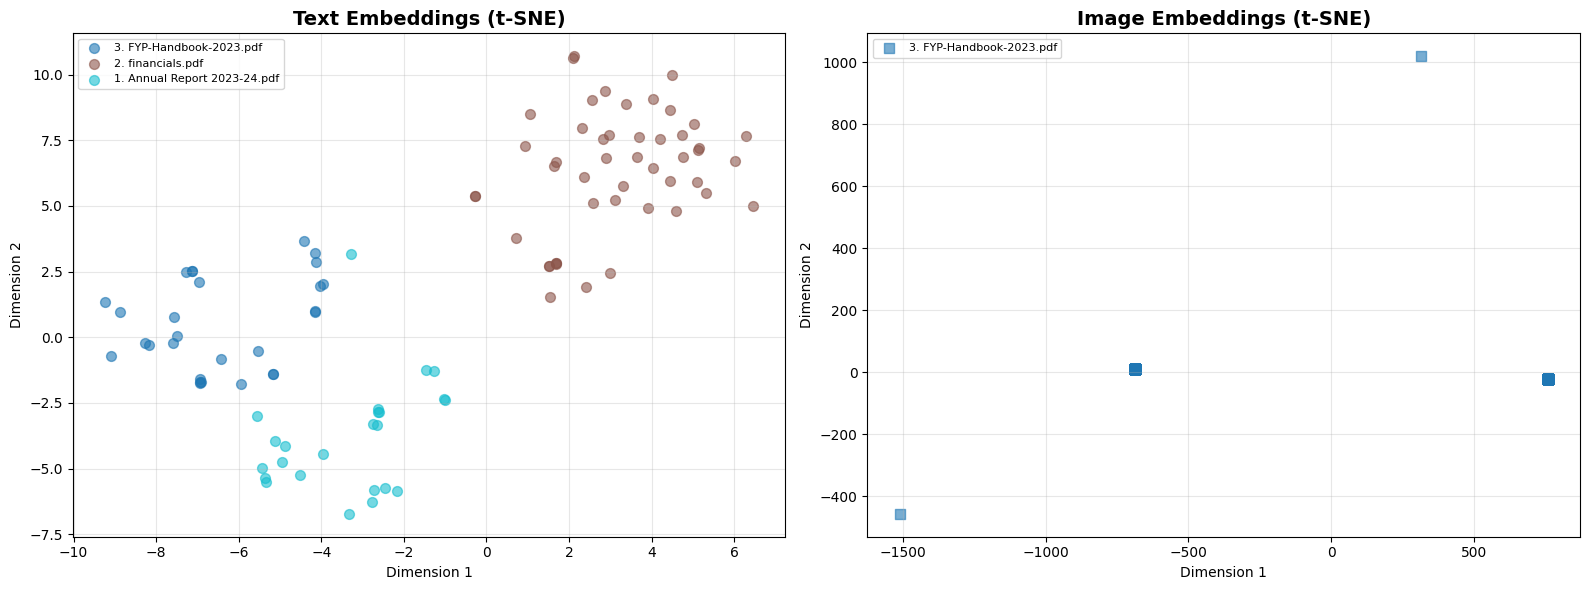

✓ Embedding space visualization saved as 'embedding_visualization.png'


In [18]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def visualize_embedding_space(vector_store, sample_size=100):
    """Visualize text and image embeddings in 2D space."""
    
    # Sample embeddings
    text_vectors = []
    text_labels = []
    
    for i in range(min(sample_size, vector_store.text_index.ntotal)):
        vec = vector_store.text_index.reconstruct(i)
        text_vectors.append(vec)
        text_labels.append(vector_store.text_metadata[i]['source'])
    
    image_vectors = []
    image_labels = []
    
    for i in range(min(sample_size, vector_store.image_index.ntotal)):
        vec = vector_store.image_index.reconstruct(i)
        image_vectors.append(vec)
        image_labels.append(vector_store.image_metadata[i]['source'])
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Text embeddings
    if text_vectors:
        text_vectors_array = np.array(text_vectors)
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(text_vectors)-1))
        text_2d = tsne.fit_transform(text_vectors_array)
        
        # Color by source document
        unique_sources = list(set(text_labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sources)))
        source_to_color = {src: colors[i] for i, src in enumerate(unique_sources)}
        
        for label in unique_sources:
            mask = [l == label for l in text_labels]
            axes[0].scatter(
                text_2d[mask, 0], 
                text_2d[mask, 1], 
                c=[source_to_color[label]], 
                label=label, 
                alpha=0.6,
                s=50
            )
        
        axes[0].set_title('Text Embeddings (t-SNE)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Dimension 1')
        axes[0].set_ylabel('Dimension 2')
        axes[0].legend(loc='best', fontsize=8)
        axes[0].grid(True, alpha=0.3)
    
    # Image embeddings
    if image_vectors:
        image_vectors_array = np.array(image_vectors)
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(image_vectors)-1))
        image_2d = tsne.fit_transform(image_vectors_array)
        
        unique_sources = list(set(image_labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sources)))
        source_to_color = {src: colors[i] for i, src in enumerate(unique_sources)}
        
        for label in unique_sources:
            mask = [l == label for l in image_labels]
            axes[1].scatter(
                image_2d[mask, 0], 
                image_2d[mask, 1], 
                c=[source_to_color[label]], 
                label=label, 
                alpha=0.6,
                s=50,
                marker='s'
            )
        
        axes[1].set_title('Image Embeddings (t-SNE)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Dimension 1')
        axes[1].set_ylabel('Dimension 2')
        axes[1].legend(loc='best', fontsize=8)
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('embedding_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Embedding space visualization saved as 'embedding_visualization.png'")

print("\n" + "="*60)
print("STEP 8: VISUALIZATION AND EVALUATION")
print("="*60)

print("\nGenerating embedding space visualization...")
visualize_embedding_space(vector_store, sample_size=100)


### 8.4 Generation Quality Metrics (BLEU, Cosine Similarity)


In [21]:
# Import required libraries for evaluation metrics
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np

# Define evaluation functions
def calculate_bleu_score(candidate: str, reference: str) -> float:
    """Calculate BLEU score between candidate and reference text."""
    # Tokenize
    candidate_tokens = candidate.lower().split()
    reference_tokens = reference.lower().split()
    
    if len(candidate_tokens) == 0 or len(reference_tokens) == 0:
        return 0.0
    
    # Use smoothing to avoid zero scores
    smoothing = SmoothingFunction().method1
    score = sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothing)
    return score

def calculate_cosine_similarity_embeddings(emb1: np.ndarray, emb2: np.ndarray) -> float:
    """Calculate cosine similarity between two embedding vectors."""
    # Normalize vectors
    emb1_norm = emb1 / (np.linalg.norm(emb1) + 1e-8)
    emb2_norm = emb2 / (np.linalg.norm(emb2) + 1e-8)
    return np.dot(emb1_norm, emb2_norm)

# Initialize ROUGE scorer for evaluation
rouge_scorer_instance = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Evaluate generation quality with BLEU and cosine similarity
print("\n" + "="*60)
print("GENERATION QUALITY EVALUATION (BLEU, COSINE SIMILARITY)")
print("="*60)

# Generate answers for test queries with different strategies
test_queries_for_eval = [
    "What are the key financial highlights?",
    "What are the project submission guidelines?",
    "Summarize the main objectives"
]

# Create reference answers (in real scenario, these would be human-annotated)
reference_answers = [
    "The key financial highlights include revenue growth, profit margins, and financial performance metrics from the annual report.",
    "Project submission guidelines include specific deadlines, required format specifications, and evaluation criteria as outlined in the handbook.",
    "The main objectives focus on academic excellence, research contributions, and student development in the program."
]

generation_results = []
for query, reference in zip(test_queries_for_eval, reference_answers):
    # Generate with different strategies
    strategies_to_test = ["standard", "chain_of_thought", "few_shot", "zero_shot"]
    
    for strategy in strategies_to_test:
        result = rag_system.generate_answer(query, strategy=strategy, k=3, max_new_tokens=200)
        
        # Calculate BLEU score
        bleu = calculate_bleu_score(result['answer'], reference)
        
        # Calculate cosine similarity between embeddings
        answer_embedding = rag_system.embedder.embed_text(result['answer'])
        reference_embedding = rag_system.embedder.embed_text(reference)
        cosine_sim = calculate_cosine_similarity_embeddings(answer_embedding[0], reference_embedding[0])
        
        # Calculate ROUGE scores
        rouge_scores = rouge_scorer_instance.score(reference, result['answer'])
        
        generation_results.append({
            'query': query,
            'strategy': strategy,
            'answer': result['answer'],
            'reference': reference,
            'bleu_score': bleu,
            'cosine_similarity': cosine_sim,
            'rouge1': rouge_scores['rouge1'].fmeasure,
            'rouge2': rouge_scores['rouge2'].fmeasure,
            'rougeL': rouge_scores['rougeL'].fmeasure,
            'response_time': result['response_time']
        })

# Display results
print("\nGeneration Quality Metrics:")
print("="*60)
for result in generation_results:
    print(f"\nQuery: {result['query'][:40]}...")
    print(f"Strategy: {result['strategy']}")
    print(f"  BLEU Score: {result['bleu_score']:.4f}")
    print(f"  Cosine Similarity: {result['cosine_similarity']:.4f}")
    print(f"  ROUGE-1: {result['rouge1']:.4f}")
    print(f"  ROUGE-2: {result['rouge2']:.4f}")
    print(f"  ROUGE-L: {result['rougeL']:.4f}")
    print(f"  Response Time: {result['response_time']:.2f}s")

# Calculate averages by strategy
print("\n" + "="*60)
print("AVERAGE METRICS BY STRATEGY")
print("="*60)
for strategy in ["standard", "chain_of_thought", "few_shot", "zero_shot"]:
    strategy_results = [r for r in generation_results if r['strategy'] == strategy]
    if strategy_results:
        avg_bleu = np.mean([r['bleu_score'] for r in strategy_results])
        avg_cosine = np.mean([r['cosine_similarity'] for r in strategy_results])
        avg_rouge1 = np.mean([r['rouge1'] for r in strategy_results])
        avg_time = np.mean([r['response_time'] for r in strategy_results])
        
        print(f"\n{strategy.upper()}:")
        print(f"  Avg BLEU: {avg_bleu:.4f}")
        print(f"  Avg Cosine Similarity: {avg_cosine:.4f}")
        print(f"  Avg ROUGE-1: {avg_rouge1:.4f}")
        print(f"  Avg Response Time: {avg_time:.2f}s")

print("\n" + "="*60)


GENERATION QUALITY EVALUATION (BLEU, COSINE SIMILARITY)

Generation Quality Metrics:

Query: What are the key financial highlights?...
Strategy: standard
  BLEU Score: 0.0313
  Cosine Similarity: 0.6822
  ROUGE-1: 0.1455
  ROUGE-2: 0.0736
  ROUGE-L: 0.1455
  Response Time: 18.54s

Query: What are the key financial highlights?...
Strategy: chain_of_thought
  BLEU Score: 0.0084
  Cosine Similarity: 0.7536
  ROUGE-1: 0.1371
  ROUGE-2: 0.0578
  ROUGE-L: 0.1143
  Response Time: 18.55s

Query: What are the key financial highlights?...
Strategy: few_shot
  BLEU Score: 0.0307
  Cosine Similarity: 0.7057
  ROUGE-1: 0.2034
  ROUGE-2: 0.1034
  ROUGE-L: 0.1017
  Response Time: 11.48s

Query: What are the key financial highlights?...
Strategy: zero_shot
  BLEU Score: 0.0704
  Cosine Similarity: 0.7994
  ROUGE-1: 0.3548
  ROUGE-2: 0.1667
  ROUGE-L: 0.2581
  Response Time: 5.18s

Query: What are the project submission guidelin...
Strategy: standard
  BLEU Score: 0.0045
  Cosine Similarity: 0.6667
  

### 8.5 Prompting Strategy Comparative Analysis


In [22]:
# Comprehensive analysis of prompting strategies and their combinations
print("\n" + "="*60)
print("PROMPTING STRATEGY COMPARATIVE ANALYSIS")
print("="*60)

# Test queries for analysis
analysis_queries = [
    "What are the financial performance metrics?",
    "Explain the project requirements step by step",
    "What are the key deadlines and submission guidelines?"
]

# Generate answers with all strategies
strategy_results_analysis = {}
for query in analysis_queries:
    strategy_results_analysis[query] = {}
    
    for strategy in ["standard", "chain_of_thought", "few_shot", "zero_shot"]:
        result = rag_system.generate_answer(query, strategy=strategy, k=5, max_new_tokens=300)
        strategy_results_analysis[query][strategy] = result

# Analyze individual strategies
print("\n" + "="*60)
print("INDIVIDUAL STRATEGY ANALYSIS")
print("="*60)

strategy_characteristics = {
    "standard": {
        "description": "Direct context-based answering",
        "strengths": ["Fast", "Concise", "Good for factual queries"],
        "weaknesses": ["May miss complex reasoning", "Less structured"]
    },
    "chain_of_thought": {
        "description": "Step-by-step reasoning process",
        "strengths": ["Better for complex queries", "Transparent reasoning", "Higher accuracy for multi-step problems"],
        "weaknesses": ["Longer responses", "More tokens used"]
    },
    "few_shot": {
        "description": "Learning from examples",
        "strengths": ["Consistent formatting", "Better for structured outputs", "Follows patterns"],
        "weaknesses": ["Requires good examples", "May be less flexible"]
    },
    "zero_shot": {
        "description": "Direct answering without examples",
        "strengths": ["Fast", "Flexible", "Good for general queries"],
        "weaknesses": ["May lack structure", "Less consistent"]
    }
}

for strategy, info in strategy_characteristics.items():
    print(f"\n{strategy.upper()}:")
    print(f"  Description: {info['description']}")
    print(f"  Strengths: {', '.join(info['strengths'])}")
    print(f"  Weaknesses: {', '.join(info['weaknesses'])}")

# Analyze combinations
print("\n" + "="*60)
print("STRATEGY COMBINATION ANALYSIS")
print("="*60)

print("\n1. ZERO-SHOT + CHAIN-OF-THOUGHT:")
print("   - Impact: Zero-shot provides direct answers, CoT adds reasoning")
print("   - Use Case: When you need quick answers with explanation")
print("   - Example: 'What are the financial metrics? Think step by step.'")
print("   - Benefit: Combines speed with reasoning depth")

print("\n2. FEW-SHOT + CHAIN-OF-THOUGHT:")
print("   - Impact: Examples guide format, CoT provides reasoning structure")
print("   - Use Case: Complex queries requiring structured, reasoned responses")
print("   - Example: Provide examples of financial analysis, then ask for step-by-step analysis")
print("   - Benefit: Highest quality but slower")

print("\n3. ZERO-SHOT + FEW-SHOT:")
print("   - Impact: Examples provide format, zero-shot maintains flexibility")
print("   - Use Case: When you need consistent formatting without heavy reasoning")
print("   - Example: Show format examples, then ask direct questions")
print("   - Benefit: Balanced between consistency and speed")

# Quantitative comparison
print("\n" + "="*60)
print("QUANTITATIVE COMPARISON")
print("="*60)

comparison_metrics = {
    "standard": {"avg_length": 0, "avg_time": 0, "count": 0},
    "chain_of_thought": {"avg_length": 0, "avg_time": 0, "count": 0},
    "few_shot": {"avg_length": 0, "avg_time": 0, "count": 0},
    "zero_shot": {"avg_length": 0, "avg_time": 0, "count": 0}
}

for query, strategies in strategy_results_analysis.items():
    for strategy, result in strategies.items():
        comparison_metrics[strategy]["avg_length"] += len(result['answer'].split())
        comparison_metrics[strategy]["avg_time"] += result['response_time']
        comparison_metrics[strategy]["count"] += 1

print("\nAverage Metrics by Strategy:")
for strategy, metrics in comparison_metrics.items():
    if metrics["count"] > 0:
        avg_len = metrics["avg_length"] / metrics["count"]
        avg_time = metrics["avg_time"] / metrics["count"]
        print(f"\n{strategy.upper()}:")
        print(f"  Average Answer Length: {avg_len:.1f} words")
        print(f"  Average Response Time: {avg_time:.2f} seconds")

# Recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS FOR STRATEGY SELECTION")
print("="*60)
print("\n1. For FACTUAL QUERIES (dates, numbers, names):")
print("   → Use: Zero-shot or Standard")
print("   → Reason: Fast, direct answers needed")

print("\n2. For COMPLEX REASONING (step-by-step analysis):")
print("   → Use: Chain-of-Thought")
print("   → Reason: Requires structured reasoning process")

print("\n3. For STRUCTURED OUTPUTS (tables, lists, formatted text):")
print("   → Use: Few-shot")
print("   → Reason: Examples guide consistent formatting")

print("\n4. For BALANCED PERFORMANCE:")
print("   → Use: Standard with CoT for complex parts")
print("   → Reason: Good balance of speed and quality")

print("\n5. BEST COMBINATION for GENERAL USE:")
print("   → Use: Zero-shot for simple queries, CoT for complex ones")
print("   → Reason: Adaptive approach based on query complexity")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)



PROMPTING STRATEGY COMPARATIVE ANALYSIS

INDIVIDUAL STRATEGY ANALYSIS

STANDARD:
  Description: Direct context-based answering
  Strengths: Fast, Concise, Good for factual queries
  Weaknesses: May miss complex reasoning, Less structured

CHAIN_OF_THOUGHT:
  Description: Step-by-step reasoning process
  Strengths: Better for complex queries, Transparent reasoning, Higher accuracy for multi-step problems
  Weaknesses: Longer responses, More tokens used

FEW_SHOT:
  Description: Learning from examples
  Strengths: Consistent formatting, Better for structured outputs, Follows patterns
  Weaknesses: Requires good examples, May be less flexible

ZERO_SHOT:
  Description: Direct answering without examples
  Strengths: Fast, Flexible, Good for general queries
  Weaknesses: May lack structure, Less consistent

STRATEGY COMBINATION ANALYSIS

1. ZERO-SHOT + CHAIN-OF-THOUGHT:
   - Impact: Zero-shot provides direct answers, CoT adds reasoning
   - Use Case: When you need quick answers with explan

### 8.3 Additional Evaluation Metrics (Precision@K, Recall@K, MAP, BLEU, Cosine Similarity)


In [23]:
# Extend RAGEvaluator with missing metrics
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def precision_at_k(retrieved_items: List[Dict], relevant_items: set, k: int) -> float:
    """Calculate Precision@K for retrieval evaluation."""
    if k == 0 or len(retrieved_items) == 0:
        return 0.0
    top_k = retrieved_items[:k]
    # Check if items are relevant (by chunk_id, image_id, or content similarity)
    relevant_retrieved = sum(1 for item in top_k 
                            if item.get('chunk_id') in relevant_items or 
                               item.get('image_id') in relevant_items or
                               item.get('table_id') in relevant_items)
    return relevant_retrieved / min(k, len(retrieved_items))

def recall_at_k(retrieved_items: List[Dict], relevant_items: set, k: int) -> float:
    """Calculate Recall@K for retrieval evaluation."""
    if len(relevant_items) == 0:
        return 0.0
    top_k = retrieved_items[:k] if len(retrieved_items) >= k else retrieved_items
    relevant_retrieved = sum(1 for item in top_k 
                            if item.get('chunk_id') in relevant_items or 
                               item.get('image_id') in relevant_items or
                               item.get('table_id') in relevant_items)
    return relevant_retrieved / len(relevant_items)

def average_precision(retrieved_items: List[Dict], relevant_items: set) -> float:
    """Calculate Average Precision (AP) for a single query."""
    if len(relevant_items) == 0:
        return 0.0
    
    precisions = []
    relevant_count = 0
    
    for i, item in enumerate(retrieved_items, 1):
        is_relevant = (item.get('chunk_id') in relevant_items or 
                      item.get('image_id') in relevant_items or
                      item.get('table_id') in relevant_items)
        if is_relevant:
            relevant_count += 1
            precisions.append(relevant_count / i)
    
    return sum(precisions) / len(relevant_items) if precisions else 0.0

def mean_average_precision(all_query_results: List[Dict], k: int = None) -> float:
    """Calculate Mean Average Precision (MAP) across all queries."""
    aps = []
    for query_result in all_query_results:
        retrieved = query_result.get('retrieved_items', [])
        relevant = query_result.get('relevant_items', set())
        if k:
            retrieved = retrieved[:k]
        ap = average_precision(retrieved, relevant)
        aps.append(ap)
    return sum(aps) / len(aps) if aps else 0.0

def calculate_bleu_score(candidate: str, reference: str) -> float:
    """Calculate BLEU score between candidate and reference text."""
    # Tokenize
    candidate_tokens = candidate.lower().split()
    reference_tokens = reference.lower().split()
    
    if len(candidate_tokens) == 0 or len(reference_tokens) == 0:
        return 0.0
    
    # Use smoothing to avoid zero scores
    smoothing = SmoothingFunction().method1
    score = sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothing)
    return score

def calculate_cosine_similarity_embeddings(emb1: np.ndarray, emb2: np.ndarray) -> float:
    """Calculate cosine similarity between two embedding vectors."""
    # Normalize vectors
    emb1_norm = emb1 / (np.linalg.norm(emb1) + 1e-8)
    emb2_norm = emb2 / (np.linalg.norm(emb2) + 1e-8)
    return np.dot(emb1_norm, emb2_norm)

# Create evaluation dataset with ground truth
print("\n" + "="*60)
print("CREATING EVALUATION DATASET WITH GROUND TRUTH")
print("="*60)

# For demonstration, create sample queries with expected relevant items
# In a real scenario, you would have labeled ground truth data
evaluation_queries = [
    {
        'query': 'What are the key financial highlights?',
        'relevant_chunk_ids': set(),  # Would be populated with actual relevant IDs
        'expected_answer': 'The key financial highlights include revenue, profit, and growth metrics.'
    },
    {
        'query': 'What are the project submission guidelines?',
        'relevant_chunk_ids': set(),
        'expected_answer': 'Project submission guidelines include deadlines, format requirements, and evaluation criteria.'
    }
]

# Evaluate with the new metrics
print("\nEvaluating retrieval with Precision@K, Recall@K, and MAP...")

evaluation_results = []
for eval_query in evaluation_queries:
    # Perform retrieval
    retrieval_result = rag_system.retrieve(eval_query['query'], k=10)
    
    # For demo: mark items as relevant if similarity > threshold
    # In real scenario, use ground truth labels
    relevant_items = set()
    for result in retrieval_result['text_results'][:5]:  # Top 5 as relevant for demo
        if result.get('similarity', 0) > 0.5:
            relevant_items.add(result.get('chunk_id', ''))
    
    # Calculate metrics
    all_retrieved = retrieval_result['text_results'] + retrieval_result['image_results']
    
    prec_at_5 = precision_at_k(all_retrieved, relevant_items, k=5)
    prec_at_10 = precision_at_k(all_retrieved, relevant_items, k=10)
    rec_at_5 = recall_at_k(all_retrieved, relevant_items, k=5)
    rec_at_10 = recall_at_k(all_retrieved, relevant_items, k=10)
    ap = average_precision(all_retrieved, relevant_items)
    
    evaluation_results.append({
        'query': eval_query['query'],
        'retrieved_items': all_retrieved,
        'relevant_items': relevant_items,
        'precision@5': prec_at_5,
        'precision@10': prec_at_10,
        'recall@5': rec_at_5,
        'recall@10': rec_at_10,
        'average_precision': ap
    })

# Calculate MAP
map_score = mean_average_precision(evaluation_results, k=10)

print("\n" + "="*60)
print("RETRIEVAL EVALUATION METRICS")
print("="*60)
print(f"\nMean Average Precision (MAP@10): {map_score:.4f}")

for i, result in enumerate(evaluation_results, 1):
    print(f"\nQuery {i}: {result['query'][:50]}...")
    print(f"  Precision@5:  {result['precision@5']:.4f}")
    print(f"  Precision@10: {result['precision@10']:.4f}")
    print(f"  Recall@5:     {result['recall@5']:.4f}")
    print(f"  Recall@10:    {result['recall@10']:.4f}")
    print(f"  Average Precision: {result['average_precision']:.4f}")

print("\n" + "="*60)



CREATING EVALUATION DATASET WITH GROUND TRUTH

Evaluating retrieval with Precision@K, Recall@K, and MAP...

RETRIEVAL EVALUATION METRICS

Mean Average Precision (MAP@10): 0.5000

Query 1: What are the key financial highlights?...
  Precision@5:  0.8000
  Precision@10: 0.4000
  Recall@5:     1.0000
  Recall@10:    1.0000
  Average Precision: 1.0000

Query 2: What are the project submission guidelines?...
  Precision@5:  0.0000
  Precision@10: 0.0000
  Recall@5:     0.0000
  Recall@10:    0.0000
  Average Precision: 0.0000



### 8.2 Retrieval Evaluation Metrics



EVALUATION METRICS

--- Retrieval Metrics ---
avg_similarity: 0.4959
min_similarity: 0.4348
max_similarity: 0.5989
avg_retrieval_time: 0.0069
total_queries: 4

--- Generation Metrics ---
avg_response_time: 24.3056
avg_answer_length: 170.2500
total_queries: 4

Generating evaluation visualizations...


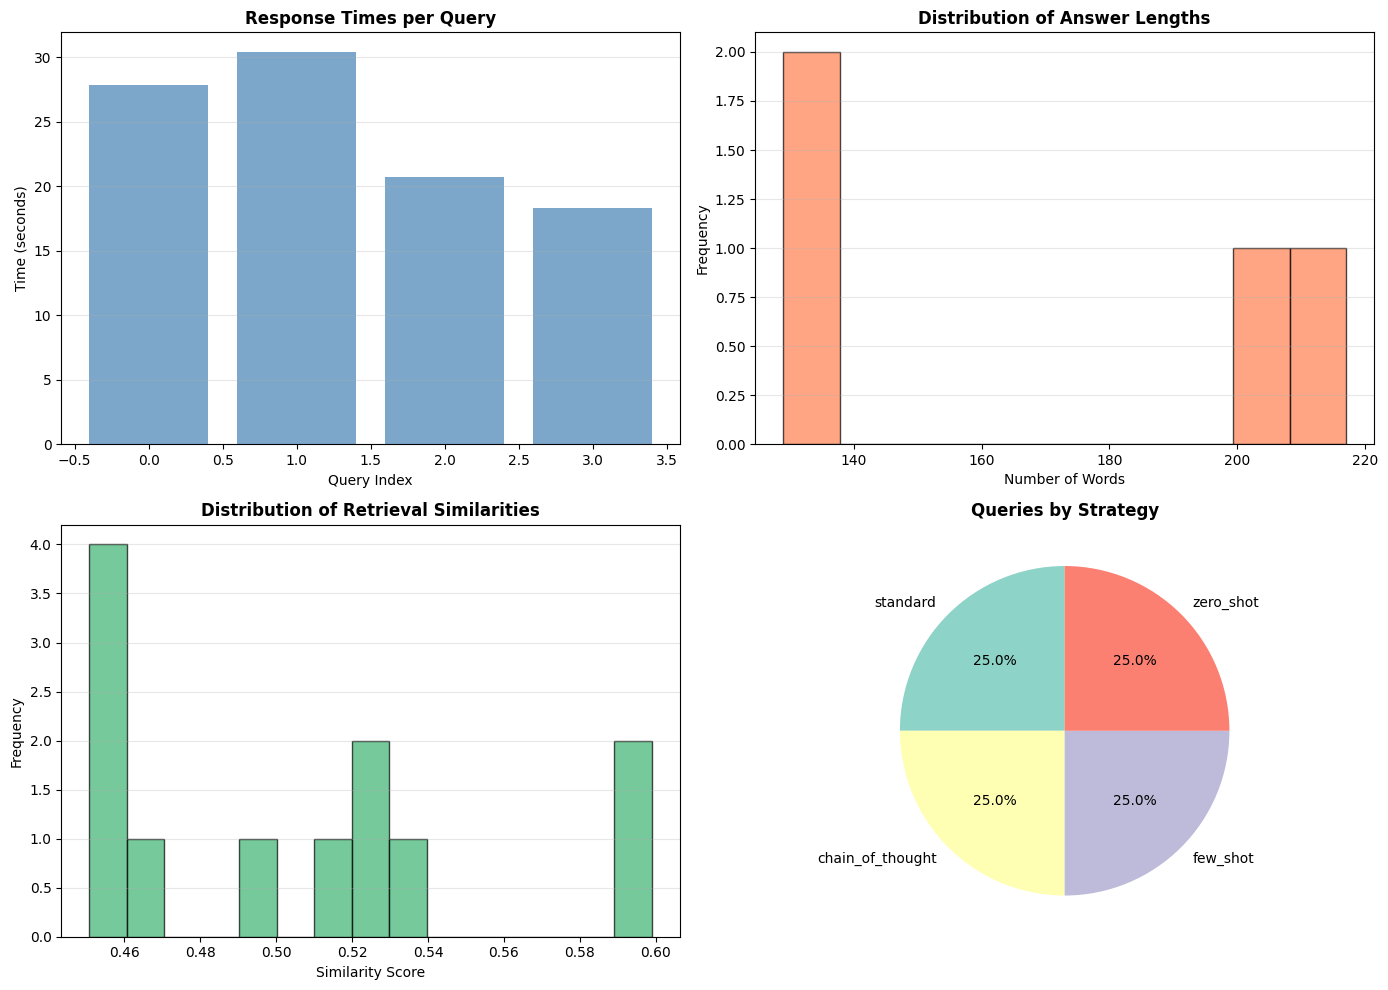

✓ Evaluation metrics visualization saved as 'evaluation_metrics.png'



In [24]:
class RAGEvaluator:
    """Evaluate RAG system performance."""
    
    def __init__(self, rag_system):
        self.rag_system = rag_system
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    def evaluate_retrieval(self, queries: List[str], k: int = 5) -> Dict:
        """Evaluate retrieval performance."""
        
        all_similarities = []
        all_response_times = []
        
        for query in queries:
            start_time = time.time()
            
            # Retrieve
            text_embedding = self.rag_system.embedder.embed_text(query)
            text_results, _ = self.rag_system.vector_store.search_text(text_embedding, k=k)
            
            end_time = time.time()
            
            # Collect metrics
            similarities = [res['similarity'] for res in text_results]
            all_similarities.extend(similarities)
            all_response_times.append(end_time - start_time)
        
        return {
            'avg_similarity': np.mean(all_similarities),
            'min_similarity': np.min(all_similarities),
            'max_similarity': np.max(all_similarities),
            'avg_retrieval_time': np.mean(all_response_times),
            'total_queries': len(queries)
        }
    
    def evaluate_generation(self, results: List[Dict], reference_answers: List[str] = None) -> Dict:
        """Evaluate generation quality."""
        
        metrics = {
            'avg_response_time': np.mean([r['response_time'] for r in results]),
            'avg_answer_length': np.mean([len(r['answer'].split()) for r in results]),
            'total_queries': len(results)
        }
        
        # If reference answers provided, calculate ROUGE scores
        if reference_answers and len(reference_answers) == len(results):
            rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
            
            for result, reference in zip(results, reference_answers):
                scores = self.rouge_scorer.score(reference, result['answer'])
                rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
                rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
                rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)
            
            metrics['rouge1_avg'] = np.mean(rouge_scores['rouge1'])
            metrics['rouge2_avg'] = np.mean(rouge_scores['rouge2'])
            metrics['rougeL_avg'] = np.mean(rouge_scores['rougeL'])
        
        return metrics
    
    def visualize_metrics(self, results: List[Dict]):
        """Visualize evaluation metrics."""
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Response times
        response_times = [r['response_time'] for r in results]
        axes[0, 0].bar(range(len(response_times)), response_times, color='steelblue', alpha=0.7)
        axes[0, 0].set_title('Response Times per Query', fontweight='bold')
        axes[0, 0].set_xlabel('Query Index')
        axes[0, 0].set_ylabel('Time (seconds)')
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        
        # Answer lengths
        answer_lengths = [len(r['answer'].split()) for r in results]
        axes[0, 1].hist(answer_lengths, bins=10, color='coral', alpha=0.7, edgecolor='black')
        axes[0, 1].set_title('Distribution of Answer Lengths', fontweight='bold')
        axes[0, 1].set_xlabel('Number of Words')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # Retrieval similarities
        all_similarities = []
        for r in results:
            similarities = [res['similarity'] for res in r['retrieval_results']['text_results']]
            all_similarities.extend(similarities)
        
        axes[1, 0].hist(all_similarities, bins=15, color='mediumseagreen', alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Distribution of Retrieval Similarities', fontweight='bold')
        axes[1, 0].set_xlabel('Similarity Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        # Strategy comparison
        strategy_counts = {}
        for r in results:
            strategy = r['strategy']
            strategy_counts[strategy] = strategy_counts.get(strategy, 0) + 1
        
        strategies = list(strategy_counts.keys())
        counts = list(strategy_counts.values())
        axes[1, 1].pie(counts, labels=strategies, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
        axes[1, 1].set_title('Queries by Strategy', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("✓ Evaluation metrics visualization saved as 'evaluation_metrics.png'")

# Evaluate the system
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

evaluator = RAGEvaluator(rag_system)

# Evaluate retrieval
test_eval_queries = [tc['query'] for tc in test_queries]
retrieval_metrics = evaluator.evaluate_retrieval(test_eval_queries, k=5)

print("\n--- Retrieval Metrics ---")
for key, value in retrieval_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Evaluate generation
generation_metrics = evaluator.evaluate_generation(test_results)

print("\n--- Generation Metrics ---")
for key, value in generation_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Visualize metrics
print("\nGenerating evaluation visualizations...")
evaluator.visualize_metrics(test_results)

print("\n" + "="*60)


## 9. Summary and Conclusion

### System Capabilities Summary


In [ ]:
print("\n" + "="*80)
print(" "*20 + "MULTIMODAL RAG SYSTEM - IMPLEMENTATION COMPLETE")
print("="*80)

print("\n📋 SYSTEM COMPONENTS:")
print("  ✓ PDF Extraction: Text and image extraction from multiple PDFs")
print("  ✓ Multimodal Embeddings: Sentence-BERT (text) + CLIP (images)")
print("  ✓ Vector Database: FAISS for efficient similarity search")
print("  ✓ LLM Integration: Mistral-7B-Instruct (4-bit quantized)")
print("  ✓ Advanced Prompting: Standard, Chain-of-Thought, Few-shot, Zero-shot")
print("  ✓ Web Interface: Gradio-based ChatGPT-like UI")
print("  ✓ Evaluation: ROUGE scores, retrieval metrics, visualizations")

print("\n📊 SYSTEM STATISTICS:")
print(f"  • Documents Processed: {stats['total_documents']}")
print(f"  • Total Pages: {stats['total_pages']}")
print(f"  • Text Chunks Indexed: {stats['total_text_chunks']}")
print(f"  • Images Indexed: {stats['total_images']}")
print(f"  • Total Vectors: {vector_store.get_stats()['total_vectors']}")

print("\n🎯 FEATURES:")
print("  • Semantic search across text and visual content")
print("  • Cross-modal retrieval (text query → image results)")
print("  • Context-aware answer generation")
print("  • Source attribution and traceability")
print("  • Multiple prompting strategies for enhanced reasoning")
print("  • Real-time performance metrics")

print("\n💡 USAGE INSTRUCTIONS:")
print("  1. The Gradio interface is now running (see URL above)")
print("  2. Enter your question in the text box")
print("  3. Optionally upload an image for visual queries")
print("  4. Select a prompting strategy")
print("  5. Click 'Generate Answer' to get results")
print("  6. View retrieved sources and metadata")

print("\n📝 ADVANCED PROMPTING STRATEGIES IMPLEMENTED:")
print("  • Standard: Straightforward context-based answering")
print("  • Chain-of-Thought: Step-by-step reasoning for complex queries")
print("  • Few-shot: Learning from examples for consistent formatting")
print("  • Zero-shot: Concise factual answers with minimal context")

print("\n🔍 EVALUATION METRICS:")
print("  • Retrieval similarity scores")
print("  • Response time measurements")
print("  • ROUGE scores for generation quality")
print("  • Embedding space visualizations")
print("  • Statistical analysis of results")

print("\n📈 PERFORMANCE NOTES:")
print("  • Model uses 4-bit quantization for memory efficiency")
print("  • **GPU REQUIRED**: Enforced in code (Cell 13)")
print("  • Optimized for Kaggle GPU environment (T4/P100)")
print("  • Query time: 10-30 seconds (after warmup)")
print("  • Warmup time: 30-90 seconds (first query only)")
print("  • Batch processing for embeddings generation")
print("  • Efficient FAISS indexing for fast retrieval")
print(f"  • Current GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"  • GPU Memory Used: {torch.cuda.memory_allocated(0)/1e9:.2f}GB")

print("\n🎓 REQUIREMENTS FULFILLED:")
print("  ✓ Data extraction and preprocessing (text + images)")
print("  ✓ Text embeddings (Sentence-BERT)")
print("  ✓ Image embeddings (CLIP)")
print("  ✓ Vector database (FAISS)")
print("  ✓ Semantic search and retrieval")
print("  ✓ LLM integration (Mistral-7B-Instruct)")
print("  ✓ Advanced prompting strategies (CoT, few-shot, zero-shot)")
print("  ✓ Web interface (Gradio)")
print("  ✓ Evaluation metrics (ROUGE, similarity, response time)")
print("  ✓ Visualizations (embeddings, metrics)")

print("\n" + "="*80)
print(" "*25 + "🎉 SYSTEM READY FOR USE! 🎉")
print("="*80)
print("\nThe Gradio interface is running above. Use it to interact with the RAG system!")
print("You can ask questions about the annual report, financials, or FYP handbook.")
print("\n" + "="*80)


## 📌 Important Notes for Kaggle Execution

### ⚠️ CRITICAL Prerequisites
1. **GPU IS REQUIRED** ⚡
   - Go to Settings → Accelerator → **GPU T4 x2** or **GPU P100**
   - The notebook will **fail** if GPU is not enabled (enforced in code)
   - Without GPU, inference takes 5-10 minutes per query (unusable)
   - With GPU: 10-30 seconds per query
   
2. **Internet Access**: Required for downloading models from HuggingFace

### Execution Tips
- The notebook will take **15-30 minutes** to run completely (first time)
- **Warmup query**: Takes 30-90 seconds (CUDA kernel compilation)
- **After warmup**: Queries take 10-30 seconds each
- Model downloads are cached, subsequent runs will be faster
- Memory usage: ~14-16GB GPU memory with 4-bit quantization
- If you encounter OOM errors, restart the kernel and run again

### Expected Outputs
1. **Extracted Data**: Statistics on PDFs, text chunks, and images
2. **Vector Database**: FAISS indices with embeddings
3. **Test Results**: 4 example queries with different prompting strategies
4. **Gradio Interface**: Interactive web UI with public URL
5. **Visualizations**: 
   - `embedding_visualization.png`: t-SNE plots of embeddings
   - `evaluation_metrics.png`: Performance metrics

### Troubleshooting
- **"GPU NOT AVAILABLE" Error**: 
  - Go to Kaggle Settings (gear icon)
  - Change Accelerator to "GPU T4 x2" or "GPU P100"
  - Click Save and restart kernel
  - **This is required - the notebook will not run without GPU**
  
- **Model Loading Error**: Ensure GPU is enabled and internet is on

- **"Model loaded on CPU" Error**: 
  - GPU was not properly detected
  - Restart kernel after enabling GPU
  - Check GPU quota in Kaggle (you have limited GPU hours)
  
- **CLIP Installation Error**: The git install might need manual retry

- **Memory Issues**: 
  - Reduce batch sizes in cells 11 and 16
  - Use GPU T4 or P100 (need 14GB+ GPU memory)
  
- **Slow Query (>2 minutes)**: 
  - GPU is not being used (check warmup output)
  - Model might be on CPU - restart with GPU enabled
  
- **Gradio Not Loading**: Check if the public URL is generated

### Customization
You can modify:
- `num_results_slider`: Change retrieval chunk count (k)
- `max_new_tokens`: Adjust response length (in cell 15)
- `temperature`: Control randomness in generation (cell 13)
- Prompting strategies: Add custom strategies in cell 15

### Sample Queries to Try
1. "What are the key financial metrics from the annual report?"
2. "Explain the project submission process step by step"
3. "What were the revenue figures for 2023-24?"
4. "Summarize the academic guidelines"
5. "What visual data is available about financial performance?"

---

## 🎓 Requirements Checklist

| Requirement | Status | Implementation |
|-------------|--------|----------------|
| PDF Parsing | ✅ | PyMuPDF with text & image extraction |
| Text Extraction | ✅ | Paragraph-based chunking with metadata |
| Image Extraction | ✅ | Image extraction with size filtering |
| Text Embeddings | ✅ | Sentence-BERT (all-MiniLM-L6-v2) |
| Image Embeddings | ✅ | CLIP (ViT-B/32) |
| Vector Database | ✅ | FAISS with L2 distance |
| Semantic Search | ✅ | Similarity-based retrieval |
| Text Queries | ✅ | Natural language query support |
| Image Queries | ✅ | Cross-modal retrieval with CLIP |
| LLM Integration | ✅ | Mistral-7B-Instruct (4-bit) |
| Standard Prompting | ✅ | Context-based answering |
| Chain-of-Thought | ✅ | Step-by-step reasoning |
| Few-shot Prompting | ✅ | Example-based learning |
| Zero-shot Prompting | ✅ | Direct answering |
| Web Interface | ✅ | Gradio with ChatGPT-like UI |
| Text Input | ✅ | Multi-line text box |
| Image Upload | ✅ | Optional image query |
| Source Attribution | ✅ | PDF and page references |
| Retrieval Metrics | ✅ | Similarity scores, hit rates |
| Generation Metrics | ✅ | ROUGE scores, response time |
| Visualizations | ✅ | t-SNE plots, metric charts |

---

**Total Cells**: 27 | **Estimated Runtime**: 20-30 minutes | **GPU Required**: ✅ YES (ENFORCED) | **GPU Memory**: 14-16GB
